In [23]:
import sys

sys.path.append("workflow/scripts")

import _schemas
import _utils
import geopandas as gpd
import numpy as np
import pandas as pd
import prepare_glohydrores as prep


In [24]:
raw_df = pd.read_csv("resources/automatic/glohydrores/data.csv")
raw_df.head()

# %%
hydro_df = _schemas.HydroSchema.validate(
    gpd.GeoDataFrame(
        {
            "powerplant_id": raw_df["ID"].apply(lambda x: "GloHydroRes_" + x),
            "name": raw_df["name"],
            "category": "hydropower",
            "technology": prep.get_technology(raw_df),
            "output_capacity_mw": raw_df["capacity_mw"],
            "start_year": raw_df["year"],
            "end_year": prep.get_end_year(raw_df),
            "status": prep.get_status(raw_df),
            "geometry": prep.get_geometry(raw_df, "plant_lon", "plant_lat"),
            "head_m": prep.get_head_m(raw_df),
            "reservoir_km3": raw_df["res_vol_km3"],
        }
    )
)
missing = hydro_df[pd.isna(hydro_df["head_m"])]
missing

,powerplant_id,name,category,technology,output_capacity_mw,start_year,end_year,status,geometry,head_m,reservoir_km3
4,GloHydroRes_GHR00005,Pul-e-Khumri Hydroelectric Power Plant Afghani...,hydropower,run of river,6.0,NaN,NaN,retired,POINT (68.71 35.9416),NaN,NaN
9,GloHydroRes_GHR00010,Bishnica 1/2,hydropower,run of river,5.9,NaN,NaN,retired,POINT (20.1374 39.9169),NaN,NaN
11,GloHydroRes_GHR00012,Cernaleve 1/2,hydropower,run of river,24.4,NaN,NaN,retired,POINT (20.55555 42.02942),NaN,NaN
14,GloHydroRes_GHR00015,Ftere 1,hydropower,run of river,3.0,NaN,NaN,retired,POINT (19.87759 40.11119),NaN,NaN
15,GloHydroRes_GHR00016,Holta,hydropower,run of river,4.7,2008.0,2088.0,retired,POINT (20.22092 40.92728),NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
7748,GloHydroRes_GHR07750,Chishimba Falls,hydropower,run of river,6.0,1971.0,2051.0,retired,POINT (30.91458 -10.11794),NaN,NaN
7753,GloHydroRes_GHR07755,Lunsemfwa,hydropower,reservoir,24.0,NaN,NaN,retired,POINT (29.11507 -14.49326),NaN,NaN
7756,GloHydroRes_GHR07758,Mosunda Falls,hydropower,run of river,5.0,NaN,NaN,retired,POINT (28.81349 -10.71458),NaN,NaN
7758,GloHydroRes_GHR07760,Musonda Falls Extension,hydropower,run of river,10.0,NaN,NaN,retired,POINT (28.81349 -10.71458),NaN,NaN



A Priority-Flood (Zhou2016 version)
C Zhou, G., Sun, Z., Fu, S., 2016. An efficient variant of the Priority-Flood algorithm for filling depressions in raster digital elevation models. Computers & Geosciences 90, Part A, 87 – 96. doi:http://dx.doi.org/10.1016/j.cageo.2016.02.021

t Zhou2016 wall-time = 0.00563966 s

A Barnes (2014) Flat Resolution Flat Mask Generation
C Barnes, R., Lehman, C., Mulla, D., 2014a. An efficient assignment of drainage direction over flat surfaces in raster digital elevation models. Computers & Geosciences 62, 128–135. doi:10.1016/j.cageo.2013.01.009

t Succeeded in = 0.000761226 s
p Setting up labels matrix...
p Setting up flat resolution mask...
p Searching for flats...
t Succeeded in = 0.00123271 s================ ] (99% - 0.0s - 1 threads)
m Cells with no flow direction = 1767
m Low edge cells               = 892
m High edge cells              = 1653
p Labeling flats...
m Unique flats = 494
p Removing flats without outlets from the queue...
  The flat he

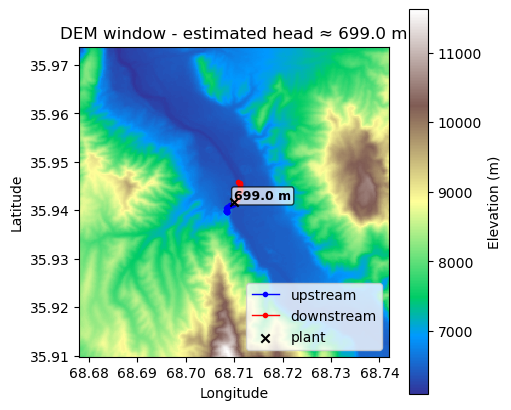

In [26]:
_utils.show_head_walk(missing.iloc[0])